---
title: "word2vec from Scratch: Turning the Meaning of Words into Numbers"
description: |
  Week 1 of the residency. Skip-gram and CBOW with negative sampling, written from scratch and
  trained on text8, then scored against WordSim-353, SimLex-999 and the Google analogy set.
author: Rosh Beed
date: '2026-06-08'
image: figures/slide-13.png
categories:
  - nlp
  - embeddings
  - week-1
jupyter: python3
---


Predict someone's income from what you know about them.

![](figures/slide-03.png){fig-alt="A person, a question mark, a small neural network, and an output of £40,000."}

A neural network takes numbers in and gives a number out. The job is to turn what you
know about a person into numbers the model can process.

Some of it's easy.

![](figures/slide-04.png){fig-alt="Gender: yes, 0 is male and 1 is female. Age: yes, a nice integer between 0 and 100. Height: yes, use centimetres. Weight: yes, kilograms. Education: hmm. City: oops. Job: oops."}

Gender is a flag. Age is already a number. Height in centimetres. Weight in
kilograms. Four features, no thought required.

Then education. The easy run stops.

## Encoding Education

![](figures/slide-05.png){fig-alt="Four encodings of education. Ordinal: none 0 through PhD 4, \"treats PhD as 4 times none\". Years of schooling: none 0 through PhD 21, \"requires some domain knowledge\". One-hot: a five-dimensional indicator, \"no assumptions, use more neurons\". Learned embeddings: a five-number vector per level, learned during training."}

There are four options on that slide.

**Ordinal.** None is 0, high school 1, bachelor 2, master 3, PhD 4. This encodes the
ordering. It also tells the model that a PhD is four times a high school diploma.
Nobody believes that.

**Years of schooling.** 0, 12, 15, 17, 21. Better, because the spacing means
something. But you had to know the answer. You supplied the domain knowledge, not
the model.

**One-hot.** Five slots, one of them set to 1. It makes no claims about ordering or
distance. The cost is a slot per category. It also makes every pair equally far
apart, so a master's and a PhD are as different as a PhD and no schooling.

**Learned embeddings.** Give each level a short list of numbers. Start them random.
Let training move them. No assumptions, no ordering imposed. The model decides what
the numbers mean.

The fourth option is what this week is about. At this scale it looks like overkill.
There are five categories. One-hot would do.

## Encoding City

![](figures/slide-06.png){fig-alt="The same list, with education now filled in as 3 for master, and city and job still marked \"oops\"."}

City has the same problem as education. No ordering, and a thousand categories
instead of five. One-hot is now a thousand slots of mostly zeros.

There is a way out.

![](figures/slide-07.png){fig-alt="City decomposed into population size 1M, average age 31, average income 22k, crime rate 4, all feeding the network."}

Break the category into features that describe it. A city is its population, its
average age, its average income, its crime rate. Four numbers instead of a
thousand. Each one means something. Two similar cities end up with similar numbers.

This is good feature engineering. A lot of real models are built this way. It also
has a ceiling, and the next feature is above it.

## Free Text

![](figures/slide-09.png){fig-alt="A free-text list of hobbies, interests and life story, several sentences long, with a red \"oops\" and a column of X marks."}

Now the form has a box that says *tell us about yourself*. Someone has written a
paragraph, and there is no obvious way to turn it into numbers.

There is no decomposition to reach for. Cities have populations. Paragraphs do not
have an agreed set of four numbers. The categories are unbounded, because anyone
can write anything. Every trick from the last three slides is gone.

The red question on that slide is the subject of week 1:

> How can we produce meaningful numbers from free text?

## The Distributional Hypothesis

What is the meaning of *bardiwac*?

> He handed her her glass of **bardiwac**.
>
> Beef dishes are made to complement the **bardiwacs**.
>
> Nigel staggered to his feet, face flushed from too much **bardiwac**.
>
> I dined off bread and cheese and this excellent **bardiwac**.

You have never seen that word before. After four sentences you know it is a drink.
Probably a red wine. Probably alcoholic.

Nobody defined it for you. You got it from the company it keeps.

This is the distributional hypothesis. **A word can be described by the words that
appear around it.** If that holds, you can compute a word's meaning from a large
pile of ordinary text. Nobody has to label anything.

The learned-embedding option is still the plan. What changed is that there is now a
way to train it without labels.

## The word2vec Recipe

![](figures/slide-13.png){fig-alt="word2vec recipe in three steps. One: treat the entire corpus as one long string, slide a window of five tokens across it, mask the middle token and use the remaining four to predict it. Two: because any given context can sensibly be completed by several different words, don't force the model to output one correct token; teach it to return a probability distribution over the whole vocabulary. Three: CBOW."}

Three steps. The second one is the one people skip.

* Slide a window over the text
* Hide the middle word
* Predict it from its neighbours

The slide draws the window five tokens wide, so four neighbours predict the
middle one. Width is a dial: the run below takes five words *either* side, which
is what Mikolov's paper uses and what the deployed service is configured with.

That gives you an enormous number of training examples from raw text, with no
annotation.

Step two is the important bit. "For dinner we served dark red ___ with steak" does
not have one right answer. It could be *bardiwac*, *wine*, *merlot* or *malbec*. So
the model is not trained to output one word. It is trained to output a **score for
every word in the vocabulary**.

That is the part that makes it work. Words that fit the same gaps end up with
similar scores, and similar scores pull their vectors together.

There are two ways to arrange that prediction.

![](figures/slide-14.png){fig-alt="Continuous bag of words: \"Hello my ? is Bes\" with the four context words going through a tokenizer, an embedding layer, averaged into one vector, and projected to predict \"name\"."}

**CBOW** takes the context and predicts the middle word. Four words go in. Each is
looked up in a table of vectors. The four vectors are averaged into one. That one
vector is used to score every word in the vocabulary.

![](figures/slide-15.png){fig-alt="Skip-gram: the word \"name\" going through a tokenizer and embedding, predicting \"Hello\", \"my\", \"is\", \"Bes\", with the negative-sampling loss formula and reference plots of the sigmoid and logarithm."}

**Skip-gram** runs it the other way. One word in, predict each of its neighbours.

I trained both.

One thing to notice: that sentence, *Hello my name is Bes*. It comes back in week 3
going through a transformer, in week 5 being transcribed by Whisper, and in week 6
being scored by a reward model. It is the course's running example. By the end you
have seen the same five words pass through six architectures.

## Negative Sampling

Step two is expensive.

To turn raw scores into probabilities you need a **softmax**. Exponentiate each
score, then divide by the total so they add up to one. The dividing is the problem.
The total is over the whole vocabulary. Here that is 71,290 words, after dropping
everything seen fewer than five times.

So every training step touches 71,290 words to learn one thing.

Negative sampling changes the question. Instead of asking *which of these 71,290 words goes here*, ask *is this pair real, or did I make it up*. Once for the true
neighbour, then five more times for words picked at random. Six comparisons instead of 71,290.

Where the random words come from matters:

* Pick uniformly and nearly every one is a rare word the model already scores near
  zero. It learns nothing.
* Pick by raw frequency and nearly all of them are `the`.
* Mikolov's papers raise the frequencies to the power 3/4, which sits between the
  two.

## Training It

The rest of this page trains that model. It trains on the whole of it: seventeen million words, 300 numbers per word.

First the corpus itself, cut into words and counted. A word that turns up two or
three times in the whole text gives the model nothing to average over, so anything
appearing fewer than ten times is dropped before training.

In [1]:
#| warning: false

# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax


import collections

import numpy as np
import torch
import torch.nn.functional as F
from huggingface_hub import hf_hub_download

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# The project's settings, not a scaled-down version of them.
EMBED, WINDOW, NEGATIVES = 300, 5, 5
MIN_COUNT, SUBSAMPLE = 5, 1e-4
BATCH, LEARNING_RATE, EPOCHS, SEED = 4096, 1e-3, 10, 42

TEXT8 = "12fc5d108454e1d48dfba7e8ea4d2b0b10225291"
path = hf_hub_download("roshbeed/ai-residency-text8", "text8",
                       repo_type="dataset", revision=TEXT8)

words = open(path).read().split()
counts = collections.Counter(words)
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]
stoi = {w: i for i, w in enumerate(vocab)}
ids = torch.tensor([stoi[w] for w in words if w in stoi], dtype=torch.int32)

print(f"{len(words):,} tokens, {len(counts):,} distinct, {len(vocab):,} kept")
print(f"'the' appears {counts['the']:,} times, "
      f"one word in {len(words) / counts['the']:.0f}")
print(f"training on {DEVICE}")


/Users/rosh/mlx/roshbeed.github.io/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


17,005,207 tokens, 253,854 distinct, 71,290 kept
'the' appears 1,061,396 times, one word in 16
training on mps


Seventeen million words, of which 71,290 distinct ones clear that
bar. Those are the words the model will learn a vector for.

One more step before training. `the` appears 1,061,396 times in that text, one
word in sixteen, and it sits next to everything, so it tells you nothing about its
neighbours. Common words get thrown
away, and the more common a word is the more often it goes.

In [2]:
frequency = torch.bincount(ids.long(), minlength=len(vocab)).double()
frequency /= frequency.sum()

keep_probability = torch.clamp(torch.sqrt(torch.tensor(SUBSAMPLE) / frequency),
                               max=1.0).float()
noise = (frequency ** 0.75 / (frequency ** 0.75).sum()).float().to(DEVICE)

print(f"'the' survives with probability {keep_probability[stoi['the']]:.3f}, "
      f"'philosophy' with {keep_probability[stoi['philosophy']]:.3f}")

SPAN = 2 * WINDOW + 1


def windows(generator):
    """One epoch's worth of context windows, resampled each time.

    Subsampling is redrawn per epoch rather than once, so a frequent word is
    dropped from some passes and kept in others. `unfold` then gives every
    sliding window as a view, which costs nothing to build.
    """
    keep = torch.rand(len(ids), generator=generator) < keep_probability[ids.long()]
    return ids[keep].unfold(0, SPAN, 1)


sample = windows(torch.Generator().manual_seed(SEED))
print(f"{sample.shape[0]:,} windows per epoch, {SPAN} words wide")


'the' survives with probability 0.040, 'philosophy' with 0.779
8,430,294 windows per epoch, 11 words wide


So `the` survives with probability 0.040 and `philosophy` almost always.
Pairing each surviving word with the five words either side of it gives ten pairs
per word, and those pairs are what the model trains on.

There are two tables of vectors. One holds a word's vector when it's the centre of
a window. The other holds it when it's somebody's neighbour. Only the first is kept
at the end. The second exists to give the first something to be scored against.

The loss below pushes the true pairs up and the invented ones down. Skip-gram
scores ten true pairs per window, one for each context word; CBOW averages the
context and scores one. That difference is visible before training even starts.

In [3]:
def new_model(generator):
    """Two matrices. The first is the one you keep."""
    inside = (torch.randn(len(vocab), EMBED, generator=generator) * 0.01)
    # Small random, not zeros. Zeros force every dot product to 0, which would make
    # the baseline below exactly (positives + negatives) * ln 2 by construction
    # rather than by measurement.
    outside = (torch.randn(len(vocab), EMBED, generator=generator) * 0.01)
    return inside.to(DEVICE).requires_grad_(), outside.to(DEVICE).requires_grad_()


def loss_on(rows, inside, outside, architecture, generator):
    """Score the real pairs up and the invented ones down.

    skip-gram takes the centre vector and predicts each of the 2*WINDOW context
    words, so it scores 2*WINDOW positives and NEGATIVES invented words for each.
    CBOW averages the context into one vector and predicts the centre, so it
    scores one positive and NEGATIVES invented words.
    """
    rows = rows.to(DEVICE).long()
    centre = rows[:, WINDOW]
    context = torch.cat((rows[:, :WINDOW], rows[:, WINDOW + 1:]), dim=1)
    batch = rows.shape[0]

    if architecture == "skipgram":
        vector = inside[centre].unsqueeze(1)
        real = F.logsigmoid((vector * outside[context]).sum(-1)).sum(-1)
        drawn = 2 * WINDOW * NEGATIVES
    else:
        vector = inside[context].mean(1).unsqueeze(1)
        real = F.logsigmoid((vector.squeeze(1) * outside[centre]).sum(-1))
        drawn = NEGATIVES

    invented_ids = torch.multinomial(noise, batch * drawn, replacement=True,
                                     generator=generator)
    invented = outside[invented_ids.view(batch, drawn)]
    fake = F.logsigmoid(-(invented @ vector.squeeze(1).unsqueeze(-1)).squeeze(-1)).sum(-1)
    return -(real + fake).mean()


# A model that knows nothing is guessing on every pair it scores, and each costs
# ln 2. That is a different number for each architecture, which is the point.
for architecture, terms in (("skipgram", 2 * WINDOW * (1 + NEGATIVES)),
                            ("cbow", 1 + NEGATIVES)):
    generator = torch.Generator(device=DEVICE).manual_seed(SEED)
    inside, outside = new_model(torch.Generator().manual_seed(SEED))
    with torch.no_grad():
        measured = loss_on(sample[:BATCH], inside, outside, architecture, generator).item()
    print(f"{architecture:9} loss before training: {measured:7.3f}, "
          f"and {terms} * ln 2 = {terms * np.log(2):7.3f}")


skipgram  loss before training:  41.589, and 60 * ln 2 =  41.589


cbow      loss before training:   4.159, and 6 * ln 2 =   4.159


Those numbers matching is a useful check. A model that knows nothing is guessing
on every pair it scores, and each guess costs ln 2. Skip-gram scores sixty pairs
per window — ten real and fifty invented — so it starts at sixty times ln 2. CBOW
scores six. Both land on their own figure to three decimals.

Be precise about what that catches, because a check you trust too far is worse
than none. It pins down the *arithmetic around* the loss: that there
really are `K` negatives and not three, that they are summed while the batch is
averaged, that nothing is double-counted. It does not catch a sign error. At
initialisation the vectors are near zero, so every dot product is near zero, and
sigmoid is a half either way. Flip the minus in front of the invented pairs and this
line still prints 41.589.

So the baseline is worth printing next to the trained loss, and worth not treating
as proof the loss is right.

Ten passes over the corpus for each architecture, then the six nearest words to a
handful of test words.

In [4]:
embeddings = {}
history = {}

for architecture in ("skipgram", "cbow"):
    cpu_generator = torch.Generator().manual_seed(SEED)
    gpu_generator = torch.Generator(device=DEVICE).manual_seed(SEED)
    inside, outside = new_model(torch.Generator().manual_seed(SEED))
    optimiser = torch.optim.Adam([inside, outside], lr=LEARNING_RATE)

    losses = []
    for epoch in range(EPOCHS):
        rows = windows(cpu_generator)
        order = torch.randperm(rows.shape[0], generator=cpu_generator)
        total = steps = 0
        for start in range(0, rows.shape[0] - BATCH, BATCH):
            loss = loss_on(rows[order[start:start + BATCH]], inside, outside,
                           architecture, gpu_generator)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            total += loss.item()
            steps += 1
        losses.append(total / steps)

    embeddings[architecture] = inside.detach()
    history[architecture] = losses
    print(f"{architecture:9} {losses[0]:7.3f} -> {losses[-1]:7.3f} "
          f"over {EPOCHS} epochs")


skipgram   25.731 ->  20.867 over 10 epochs


cbow        2.487 ->   1.351 over 10 epochs


Down from each architecture's own coin baseline, which is the only thing either
number means on its own. What it bought is easier to see in the vectors. Here are the six nearest words
to a handful of test words, by cosine similarity:

In [5]:
space = F.normalize(embeddings["skipgram"], dim=1)


def nearest(word, k=6):
    similarity = space @ space[stoi[word]]
    similarity[stoi[word]] = -1
    return [vocab[i] for i in similarity.topk(k).indices.tolist()]


for word in ("king", "france", "computer", "three", "war", "music"):
    print(f"{word:10} {', '.join(nearest(word))}")


king       crowned, kings, throne, reigned, anshan, ethelwulf
france     french, germany, belgium, spain, paris, philippe
computer   computers, hardware, computing, software, microcomputer, graphics
three      four, two, one, five, six, seven
war        civil, wwii, hostilities, battle, corregidor, ii
music      musical, musicians, folk, melodic, danceable, allmusic


Nothing labelled any of that. The lists come out of counting which words turn up
near which.

Three hundred numbers per word is more than can be drawn, so the last step is to
flatten them onto a plane. Take three groups of words that have nothing in common except
their category, find the two directions that separate the group of them most, and
plot only those.

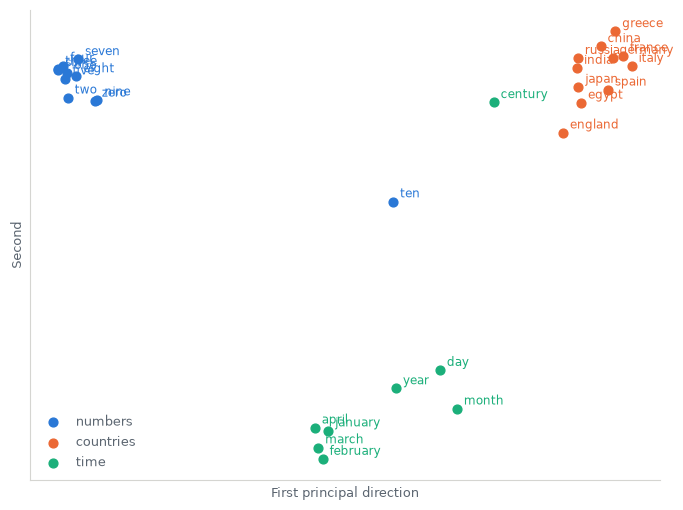

In [6]:
#| label: fig-space
#| fig-cap: Thirty words from three categories, projected onto the two directions that spread them furthest apart. Nothing in training was told these categories exist.
#| fig-alt: A scatter plot of thirty labelled words in three colours. The number words sit in one corner, packed so tightly their labels overlap; the country names spread across the opposite side and the time words sit below, with no overlap between the three groups.

import matplotlib.pyplot as plt

GROUPS = {
    "numbers": ["one", "two", "three", "four", "five", "six", "seven", "eight",
                "nine", "ten", "zero"],
    "countries": ["france", "germany", "italy", "spain", "russia", "china", "japan",
                  "england", "greece", "egypt", "india"],
    "time": ["january", "february", "march", "april", "year", "century", "day", "month"],
}
present = {name: [w for w in words if w in stoi] for name, words in GROUPS.items()}
picked = [w for words in present.values() for w in words]

# Principal components of just these words: the two directions along which this
# particular set of thirty spreads out most. Not a general map of the space.
M = space[[stoi[w] for w in picked]].cpu().numpy()
M = M - M.mean(0)
xy = M @ np.linalg.svd(M, full_matrices=False)[2][:2].T

fig, ax = figure(width=7.0, height=5.2)
start = 0
for (name, words), colour in zip(present.items(), COLOURS):
    points = xy[start:start + len(words)]
    ax.scatter(points[:, 0], points[:, 1], s=40, color=colour, zorder=3, label=name)
    for word, (x, y) in zip(words, points):
        ax.annotate(word, (x, y), xytext=(5, 3), textcoords="offset points",
                    fontsize=8.5, color=colour)
    start += len(words)

ax.legend(frameon=False, fontsize=9, labelcolor=MUTED, loc="best")
style_axes(ax, "First principal direction", "Second", grid=None)
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()


Three groups in three regions. That is the answer to the red question: every word
now has 300 numbers attached, and the numbers put related words near each other.
Nothing was labelled to make it happen.

The number words are packed so tightly their labels sit on top of each other,
because `three` and `four` and `seven` turn up in almost identical company. `ten` has drifted away from them, and `zero` and `two` sit out
at the edge of the group. The distances are carrying information, not just the
clusters.

To turn a paragraph into numbers, look up each word and average. Crude, and enough
to close the loop we opened with:

![](figures/slide-10.png){fig-alt="The same person and network diagram, now with a Description field carrying the free-text summary into the model alongside gender, age, height, weight and education, producing £40,000."}

The free-text box goes in. Every feature on that form is now a number.

## How Good Are They

Three standard benchmarks, scored against the numbers the word2vec paper reported
on this same corpus. The untrained column is the same matrices before a single
gradient step.


In [7]:
from scipy.stats import spearmanr

EVAL = "80a775cc6dc61771da6ff6ea21f5703ae665a2e2"
benchmark_file = {
    name: hf_hub_download("roshbeed/ai-residency-word-embeddings-eval", name,
                          repo_type="dataset", revision=EVAL)
    for name in ("wordsim353.txt", "simlex999.txt", "questions-words.txt")
}


def similarity(vectors, path):
    """Spearman between cosine similarity and the human score."""
    rows = [line.split() for line in open(path, encoding="utf-8").read().splitlines()]
    pairs = [(r[0].lower(), r[1].lower(), float(r[2])) for r in rows if len(r) == 3]
    usable = [(stoi[a], stoi[b], s) for a, b, s in pairs if a in stoi and b in stoi]
    unit = F.normalize(vectors, dim=1)
    left = unit[torch.tensor([u[0] for u in usable], device=vectors.device)]
    right = unit[torch.tensor([u[1] for u in usable], device=vectors.device)]
    predicted = (left * right).sum(1).cpu().tolist()
    return float(spearmanr(predicted, [u[2] for u in usable])[0]), len(usable) / len(pairs)


def analogies(vectors, path, max_vocab=30_000):
    """`a is to b as c is to ?`, answered over the most frequent words only."""
    questions, semantic = [], True
    for line in open(path, encoding="utf-8").read().splitlines():
        if line.startswith(":"):
            semantic = not line.split()[1].startswith("gram")
            continue
        fields = line.lower().split()
        if len(fields) == 4:
            questions.append((*fields, semantic))

    candidates = min(max_vocab, vectors.shape[0])
    unit = F.normalize(vectors[:candidates], dim=1)
    usable = [tuple(stoi[w] for w in q[:4]) for q in questions
              if all(w in stoi and stoi[w] < candidates for w in q[:4])]

    correct = 0
    for start in range(0, len(usable), 512):
        chunk = torch.tensor(usable[start:start + 512], device=vectors.device)
        query = F.normalize(unit[chunk[:, 1]] - unit[chunk[:, 0]] + unit[chunk[:, 2]], dim=1)
        scores = query @ unit.T
        # a, b and c are excluded, not merely deprioritised: the query vector is a
        # short hop from c, so without this the answer is almost always c itself.
        scores.scatter_(1, chunk[:, :3], float("-inf"))
        correct += (scores.argmax(1) == chunk[:, 3]).sum().item()
    return correct / len(usable), len(usable) / len(questions)


untrained, _ = new_model(torch.Generator().manual_seed(SEED))
scored = {"untrained": untrained.detach(), **embeddings}

print(f"{'':20}" + "".join(f"{name:>12}" for name in scored) + "  published  coverage")
for label, scorer, published in (
        ("WordSim-353", lambda v: similarity(v, benchmark_file["wordsim353.txt"]), 0.68),
        ("SimLex-999", lambda v: similarity(v, benchmark_file["simlex999.txt"]), 0.30),
        ("Google analogies", lambda v: analogies(v, benchmark_file["questions-words.txt"]), 0.38)):
    values, coverage = [], 0.0
    for vectors in scored.values():
        score, coverage = scorer(vectors)
        values.append(score)
    print(f"{label:20}" + "".join(f"{v:12.3f}" for v in values)
          + f"{published:11.2f}{coverage:10.2f}")


                       untrained    skipgram        cbow  published  coverage
WordSim-353                0.063       0.733       0.741       0.68      0.99
SimLex-999                -0.001       0.316       0.308       0.30      0.99


Google analogies           0.000       0.460       0.444       0.38      0.63


The untrained column is not decoration. A loss of 10.02 reads like a trained model
until you know that an untrained one reports 11.09.


## Checking the Vectors

The famous claim is that directions in this space mean something. Take `king`,
subtract `man`, add `woman`, and you should land near `queen`. Three more of the
same shape, and the rank `queen` actually gets.


In [8]:
def analogy(a, b, c, k=3):
    """b is to a as ? is to c, with all three query words excluded."""
    query = F.normalize(space[stoi[b]] - space[stoi[a]] + space[stoi[c]], dim=0)
    scores = space @ query
    scores[[stoi[a], stoi[b], stoi[c]]] = float("-inf")
    order = scores.argsort(descending=True)
    return [vocab[i] for i in order[:k].tolist()], order


for a, b, c in (("big", "bigger", "small"), ("walk", "walked", "run"),
                ("france", "paris", "italy"), ("man", "king", "woman")):
    top, _ = analogy(a, b, c)
    print(f"{b} - {a} + {c:8} -> {', '.join(top)}")

_, order = analogy("man", "king", "woman")
rank = (order == stoi["queen"]).nonzero().item() + 1
print(f"\nqueen is ranked {rank} for king - man + woman")

family = [("man", "woman", "king", "queen"), ("father", "mother", "son", "daughter"),
          ("boy", "girl", "brother", "sister"), ("father", "mother", "grandfather",
          "grandmother"), ("husband", "wife", "brother", "sister")]
hits = sum(analogy(a, b, c, k=1)[0][0] == d for a, b, c, d in family
           if all(w in stoi for w in (a, b, c, d)))
print(f"{hits} of {len(family)} family analogies land first")


bigger - big + small    -> large, smaller, larger
walked - walk + run      -> runs, unearned, running
paris - france + italy    -> bologna, turin, venice
king - man + woman    -> queen, crowned, reigned

queen is ranked 1 for king - man + woman
3 of 5 family analogies land first


`queen` comes first. That is the result the claim promises, and this corpus has a
reputation for not giving it.

The three that look easier are the ones that miss. `walked - walk + run` puts
`runs` and `running` at the top and never reaches `ran`. `paris - france + italy`
gives `bologna`, `turin` and `venice`: Italian cities, the right region of the
space, the wrong city. `bigger - big + small` finds `smaller` second rather than
first.

So the directions are there and reading one exact word off them is closer to a
coin flip. The Google set scores 0.460 for the same reason — the arithmetic points
the right way far more often than it lands on the intended word. Three of the five
family analogies come first, which is the same story from the other side.

This text is 17 million words of Wikipedia, and `king` appears mostly in lists of
monarchs and succession prose. The gender direction survives that; the precision
does not.

The same thing at the scale of the full run, on the 200 most frequent words rather
than thirty chosen ones, and through t-SNE rather than a flat projection:

![](figures/tsne_embeddings.png){fig-alt="t-SNE projection of the learned embedding space, the 200 most frequent words, with number words, nationalities and modal verbs each falling into their own region"}

## Conclusion

Week 1 starts with a feature engineering problem and ends with a way to solve it.

* Some features are already numbers
* Some categories can be decomposed into numbers by hand
* Free text can be neither, so you learn the numbers instead
* The training signal is free, because the text supplies its own labels

The second project of week 1 is the income model with a real dataset. Predict how
many upvotes a Hacker News post gets, from its title, its timestamp, its link and
its author. A number to predict, some easy features, and one free-text field.

These vectors fill that field in. [That post is
here](../2026-06-11-hacker-news-upvotes/).

![](figures/fig12-word2vec-bert-gpt.png){fig-alt="Three panels: word2vec predicting a masked word from an averaged window, BERT predicting two masked tokens from the full bidirectional sequence, and GPT predicting the next token causally"}

The window that makes this work is also what limits it. CBOW and skip-gram only
ever see five words either side. Replace that fixed window with attention over the
whole sequence and you get BERT and GPT. That is where week 3 goes.

The full project, with the sweep and the deployed API, is
[on GitHub](https://github.com/RoshBeed/ai-residency/tree/main/services/word-embeddings).
